# Análise Exploratória com APIs Externas

## 1. Clima e Demanda de Serviços

Este notebook investiga a relação entre variáveis climáticas e a demanda por serviços públicos no município do Rio de Janeiro, medida pelo volume e pela eficácia de atendimento dos chamados à Central 1746, no período 2023-2024.

Estruturei a análise em quatro camadas:
1. **Correlação direta** entre temperatura/chuva do dia e volume de chamados.
2. **Controle pelo dia da semana**, para isolar o efeito genuíno do clima do padrão semanal de demanda.
3. **Efeito de acúmulo e defasagem**, testando se o impacto da chuva se manifesta com atraso.
4. **Eficácia de resposta**, verificando se o clima afeta não apenas o volume, mas a capacidade de resolver os chamados.

A premissa central é tratar o clima como um estressor urbano e identificar quais categorias de serviço são mais sensíveis a ele, tanto em demanda quanto em capacidade de resposta. Assim como uma crise fiscal não é causada pelo déficit de um único mês, a maior parte dos danos urbanos no Rio não é causada pela pancada de um dia.

### Configuração do Ambiente

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import requests_cache
import openmeteo_requests
from retry_requests import retry
from dotenv import load_dotenv
import basedosdados as bd

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

load_dotenv()
project_id = os.getenv("BILLING_PROJECT_ID")

### Coleta de Dados

#### Dados climáticos

Utilizei a API de arquivo histórico da Open-Meteo para obter, no ponto geográfico do Rio de Janeiro, duas variáveis diárias para o período 2023-2024:
- **temp_max**: temperatura máxima diária (°C)
- **chuva**: precipitação total diária (mm)

In [2]:
geo_url = (
    "https://geocoding-api.open-meteo.com/v1/search"
    "?name=Rio+de+Janeiro&count=1&language=pt&format=json"
)
geo_data = requests.get(geo_url).json()
lat = geo_data["results"][0]["latitude"]
lon = geo_data["results"][0]["longitude"]
print(f"Coordenadas: Lat {lat:.4f}, Lon {lon:.4f}")

Coordenadas: Lat -22.9064, Lon -43.1822


In [3]:
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

In [4]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2023-01-01",
    "end_date": "2024-12-31",
    "daily": ["temperature_2m_max", "precipitation_sum"],
    "timezone": "America/Sao_Paulo",
}
responses = openmeteo.weather_api(url, params=params)
response = responses[0]

In [5]:
daily = response.Daily()
datas = pd.date_range(
    start=pd.to_datetime(daily.Time(), unit="s", utc=True),
    end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=daily.Interval()),
    inclusive="left",
)

df_clima = pd.DataFrame({
    "data": pd.to_datetime(datas.tz_convert("America/Sao_Paulo").date),
    "temp_max": daily.Variables(0).ValuesAsNumpy(),
    "chuva": daily.Variables(1).ValuesAsNumpy(),
})

print(f"Período: {df_clima['data'].min().date()} a {df_clima['data'].max().date()}")
print(f"Dias sem chuva: {(df_clima['chuva'] == 0).sum()} ({(df_clima['chuva'] == 0).mean()*100:.1f}%)")
df_clima.describe().round(2)

Período: 2023-01-01 a 2024-12-31
Dias sem chuva: 329 (45.0%)


,data,temp_max,chuva
count,731,731.00,731.00
mean,2024-01-01 00:00:00,27.85,2.84
min,2023-01-01 00:00:00,18.27,0.00
25%,2023-07-02 12:00:00,25.10,0.00
50%,2024-01-01 00:00:00,27.72,0.20
75%,2024-07-01 12:00:00,30.17,2.50
max,2024-12-31 00:00:00,40.02,136.90
std,NaN,3.64,7.57


#### Dados de chamados (Central 1746)

Além de `tipo` e volume diário, incluí `subtipo` e `situacao` na consulta ao BigQuery. A coluna `situacao` permite calcular a taxa de encerramento dos chamados, abrindo caminho para analisar não apenas se o clima aumenta a demanda, mas se ele compromete a capacidade de resposta da prefeitura.

In [6]:
query = """
SELECT
    DATE(data_inicio) AS data,
    tipo,
    subtipo,
    situacao,
    COUNT(*)          AS volume
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE data_particao BETWEEN '2023-01-01' AND '2024-12-31'
GROUP BY 1, 2, 3, 4
"""
df_chamados_raw = bd.read_sql(query, billing_project_id=project_id)
df_chamados_raw["data"] = pd.to_datetime(df_chamados_raw["data"])

print(f"Tipos únicos de chamado: {df_chamados_raw['tipo'].nunique()}")
print(f"Subtipos únicos: {df_chamados_raw['subtipo'].nunique()}")
print(f"Situações: {df_chamados_raw['situacao'].value_counts().to_dict()}")
print(f"Total de registros: {len(df_chamados_raw):,}")

Downloading: 100%|██████████|
Tipos únicos de chamado: 522
Subtipos únicos: 2786
Situações: {'Encerrado': 301070, 'Não Encerrado': 10064}
Total de registros: 311,134


In [7]:
# Marcar chamados encerrados e computar coluna de volume encerrado
df_chamados_raw["is_encerrado"] = df_chamados_raw["situacao"] == "Encerrado"
df_chamados_raw["volume_encerrado"] = df_chamados_raw["volume"].where(
    df_chamados_raw["is_encerrado"], 0
)

# Agregar para a granularidade tipo x dia (usada no restante da análise)
df_chamados_dia = (
    df_chamados_raw
    .groupby(["data", "tipo"])
    .agg(
        volume           = ("volume",           "sum"),
        volume_encerrado = ("volume_encerrado", "sum"),
    )
    .reset_index()
)

df_chamados_dia["taxa_resolucao"] = (
    df_chamados_dia["volume_encerrado"] / df_chamados_dia["volume"].replace(0, pd.NA)
)

df_chamados_dia["dia_semana"] = df_chamados_dia["data"].dt.dayofweek

print(f"Registros tipo x dia: {len(df_chamados_dia):,}")
print(f"Taxa de resolução média: {df_chamados_dia['taxa_resolucao'].mean():.2%}")

Registros tipo x dia: 112,099
Taxa de resolução média: 98.96%


### Preparação dos Dados

A base contém centenas de tipos únicos de chamado. A maioria é burocrático-administrativa (ouvidorias, portais internos) e não tem ligação plausível com o clima. Incluí-los numa análise de correlação produziria correlações espúrias a partir de amostras pequenas.

Optei por construir um mapa de macro-categorias, selecionando apenas os tipos com nexo causal plausível com variáveis climáticas e agrupando-os em sete famílias.

In [8]:
mapa_categorias = {
    # INFRAESTRUTURA E DRENAGEM
    'Drenagem e Saneamento': 'Infraestrutura e Drenagem',
    'Inundação, alagamento': 'Infraestrutura e Drenagem',
    'Manutenção de rios e canais': 'Infraestrutura e Drenagem',
    'Enchentes e saneamento': 'Infraestrutura e Drenagem',
    'Sistema de drenagem': 'Infraestrutura e Drenagem',
    'Limpeza de margens de rios': 'Infraestrutura e Drenagem',
    'Saneamento básico': 'Infraestrutura e Drenagem',
    'Rio-Águas': 'Infraestrutura e Drenagem',
    'Obras de controle de enchentes': 'Infraestrutura e Drenagem',

    # DEFESA CIVIL E GEOTECNIA
    'Defesa civil': 'Defesa Civil e Geotecnia',
    'Documento - Defesa Civil': 'Defesa Civil e Geotecnia',
    'Geotecnia': 'Defesa Civil e Geotecnia',
    'GEORIO': 'Defesa Civil e Geotecnia',
    'Encostas': 'Defesa Civil e Geotecnia',
    'Interdição de imóvel': 'Defesa Civil e Geotecnia',
    'Vistorias - Defesa Civil': 'Defesa Civil e Geotecnia',
    'Estrutura de Imóvel': 'Defesa Civil e Geotecnia',

    # CONSERVAÇÃO E PAVIMENTAÇÃO
    'Conservação de vias': 'Conservação e Pavimentação',
    'Pavimentação': 'Conservação e Pavimentação',
    'Tapa-buraco': 'Conservação e Pavimentação',
    'Recapeamento asfáltico': 'Conservação e Pavimentação',
    'Vias públicas': 'Conservação e Pavimentação',
    'Calçadas': 'Conservação e Pavimentação',

    # SAÚDE E VETORES
    'Arboviroses': 'Saúde e Vetores',
    'Controle de vetores': 'Saúde e Vetores',
    'Controle de roedores e caramujos': 'Saúde e Vetores',
    'Vigilância Epidemiológica': 'Saúde e Vetores',
    'Zoonoses': 'Saúde e Vetores',
    'Vetores ': 'Saúde e Vetores',
    'Saúde': 'Saúde e Vetores',

    # SERVIÇOS URBANOS
    'Iluminação Pública': 'Serviços Urbanos',
    'Manutenção de iluminação pública': 'Serviços Urbanos',
    'Coleta domiciliar': 'Serviços Urbanos',
    'Limpeza de logradouros': 'Serviços Urbanos',
    'Sinalização Semafórica': 'Serviços Urbanos',
    'Semáforo': 'Serviços Urbanos',
    'Limpeza': 'Serviços Urbanos',
    'Coleta Seletiva': 'Serviços Urbanos',

    # SOCIAL E ASSISTÊNCIA
    'Atendimento Social': 'Social e Assistência',
    'Pedidos de acolhimento': 'Social e Assistência',
    'Abrigos': 'Social e Assistência',
    'Assistência Social/Programas sociais': 'Social e Assistência',

    # ORDEM PÚBLICA E LAZER
    'Estacionamento irregular': 'Ordem Pública e Lazer',
    'Estacionamento ': 'Ordem Pública e Lazer',
    'Comércio ambulante': 'Ordem Pública e Lazer',
    'Perturbação do sossego': 'Ordem Pública e Lazer',
    'Poluição sonora': 'Ordem Pública e Lazer',
    'Ocupação de área pública': 'Ordem Pública e Lazer',
    'Praias': 'Ordem Pública e Lazer',
    'Limpeza de praias': 'Ordem Pública e Lazer',
    'Ordem pública': 'Ordem Pública e Lazer',
}

In [9]:
# Merge com clima e filtro para categorias relevantes
df_chamados_dia["data"] = pd.to_datetime(df_chamados_dia["data"])
df_clima["data"] = pd.to_datetime(df_clima["data"])

df_final = df_chamados_dia.merge(df_clima, on="data", how="inner")

df_analise_clima = df_final[df_final["tipo"].isin(mapa_categorias.keys())].copy()
df_analise_clima["macro_tipo"] = df_analise_clima["tipo"].map(mapa_categorias)

print(f"Volume total de chamados (todas as categorias): {df_final['volume'].sum():,}")
print(f"Volume filtrado (macro-categorias): {df_analise_clima['volume'].sum():,}")

Volume total de chamados (todas as categorias): 2,792,446
Volume filtrado (macro-categorias): 1,291,513


### Análise

#### 3.1 Correlação Direta (volume x clima)

Antes de filtrar, calculei a correlação de todos os tipos com chuva e temperatura para motivar a escolha do filtro.

In [10]:
correlacoes_bruto = (
    df_final
    .groupby("tipo")[["volume", "temp_max", "chuva"]]
    .corr(numeric_only=True)
    .unstack()
    .iloc[:, [1, 2]]
)
correlacoes_bruto.columns = ["corr_temp", "corr_chuva"]
correlacoes_bruto.sort_values("corr_chuva", ascending=False).head()

,corr_temp,corr_chuva
tipo,,
Capacitação,-0.926943,1.000000
Portal da Prefeitura-SEGOVI,-0.576557,0.998325
Processos administrativos - Seconserva,-0.198804,0.939041
Informação solicitada - SMC,0.421828,0.894664
Gestão Administrativa,0.068323,0.643202


Os tipos com maior correlação com chuva são administrativos ("Capacitação", "Portal da Prefeitura", "Processos administrativos") com amostras muito pequenas. Isso é sinal clássico de correlações espúrias. A partir daqui, trabalho com foco nas macro-categorias definidas acima.

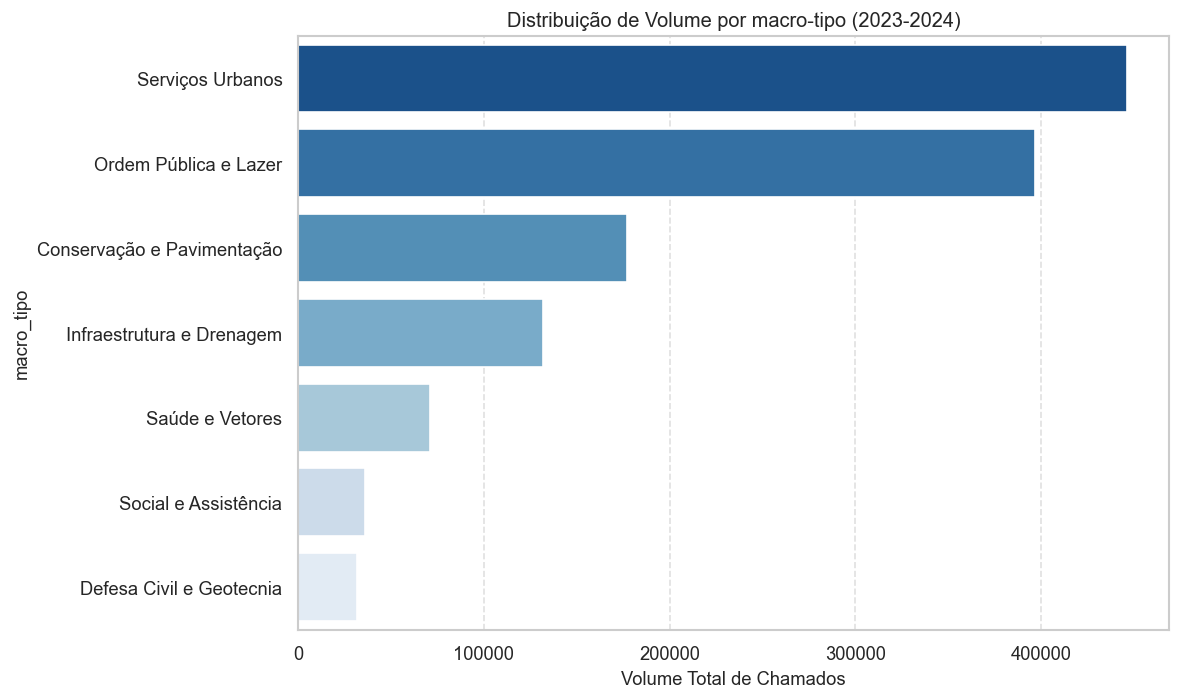

In [11]:
resumo_macro = (
    df_analise_clima.groupby("macro_tipo")["volume"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=resumo_macro, x="volume", y="macro_tipo", palette="Blues_r")
plt.title("Distribuição de Volume por macro-tipo (2023-2024)", fontsize=12)
plt.xlabel("Volume Total de Chamados")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
correlacao_macro = (
    df_analise_clima
    .groupby(["macro_tipo", "data"])[["volume", "temp_max", "chuva"]]
    .sum(numeric_only=True)
    .groupby(level=0)
    .corr()
    .unstack()
    .iloc[:, [1, 2]]
)
correlacao_macro.columns = ["corr_temp", "corr_chuva"]
display(correlacao_macro.sort_values("corr_chuva", ascending=False))

,corr_temp,corr_chuva
macro_tipo,,
Defesa Civil e Geotecnia,0.575131,0.195999
Saúde e Vetores,0.421327,0.022476
Infraestrutura e Drenagem,0.261094,-0.000333
Social e Assistência,0.110210,-0.005018
Serviços Urbanos,0.539079,-0.028317
Conservação e Pavimentação,0.315790,-0.057401
Ordem Pública e Lazer,0.108019,-0.255498


**Temperatura:** a correlação com a temperatura é consistentemente mais alta do que com a chuva em quase todas as categorias. Defesa Civil e Geotecnia (0.57) e Serviços Urbanos (0.53) mostram correlações moderadas a fortes, o que faz sentido pelo aumento do turismo e maior ocupação das ruas no verão carioca.

**Ordem Pública e Lazer:** é a única categoria com correlação negativa relevante com chuva, o que é plausível, afinal, menos pessoas na rua em dias de chuva significa menos conflitos de ordem pública.

**Infraestrutura e Drenagem:** a correlação direta com chuva é praticamente nula, o que parece contraintuitivo. Minha hipótese é que o efeito climático nessa categoria se manifesta com defasagem, e que parte da correlação observada pode ser artefato do padrão semanal.

Antes de investigar a defasagem, preciso isolar o efeito do dia da semana.

#### 3.2 Controle pelo Dia da Semana

O volume de chamados varia estruturalmente ao longo da semana: finais de semana têm menos atendentes e menos gente circulando. Se esse padrão não for controlado, ele pode inflar ou mascarar correlações com o clima.

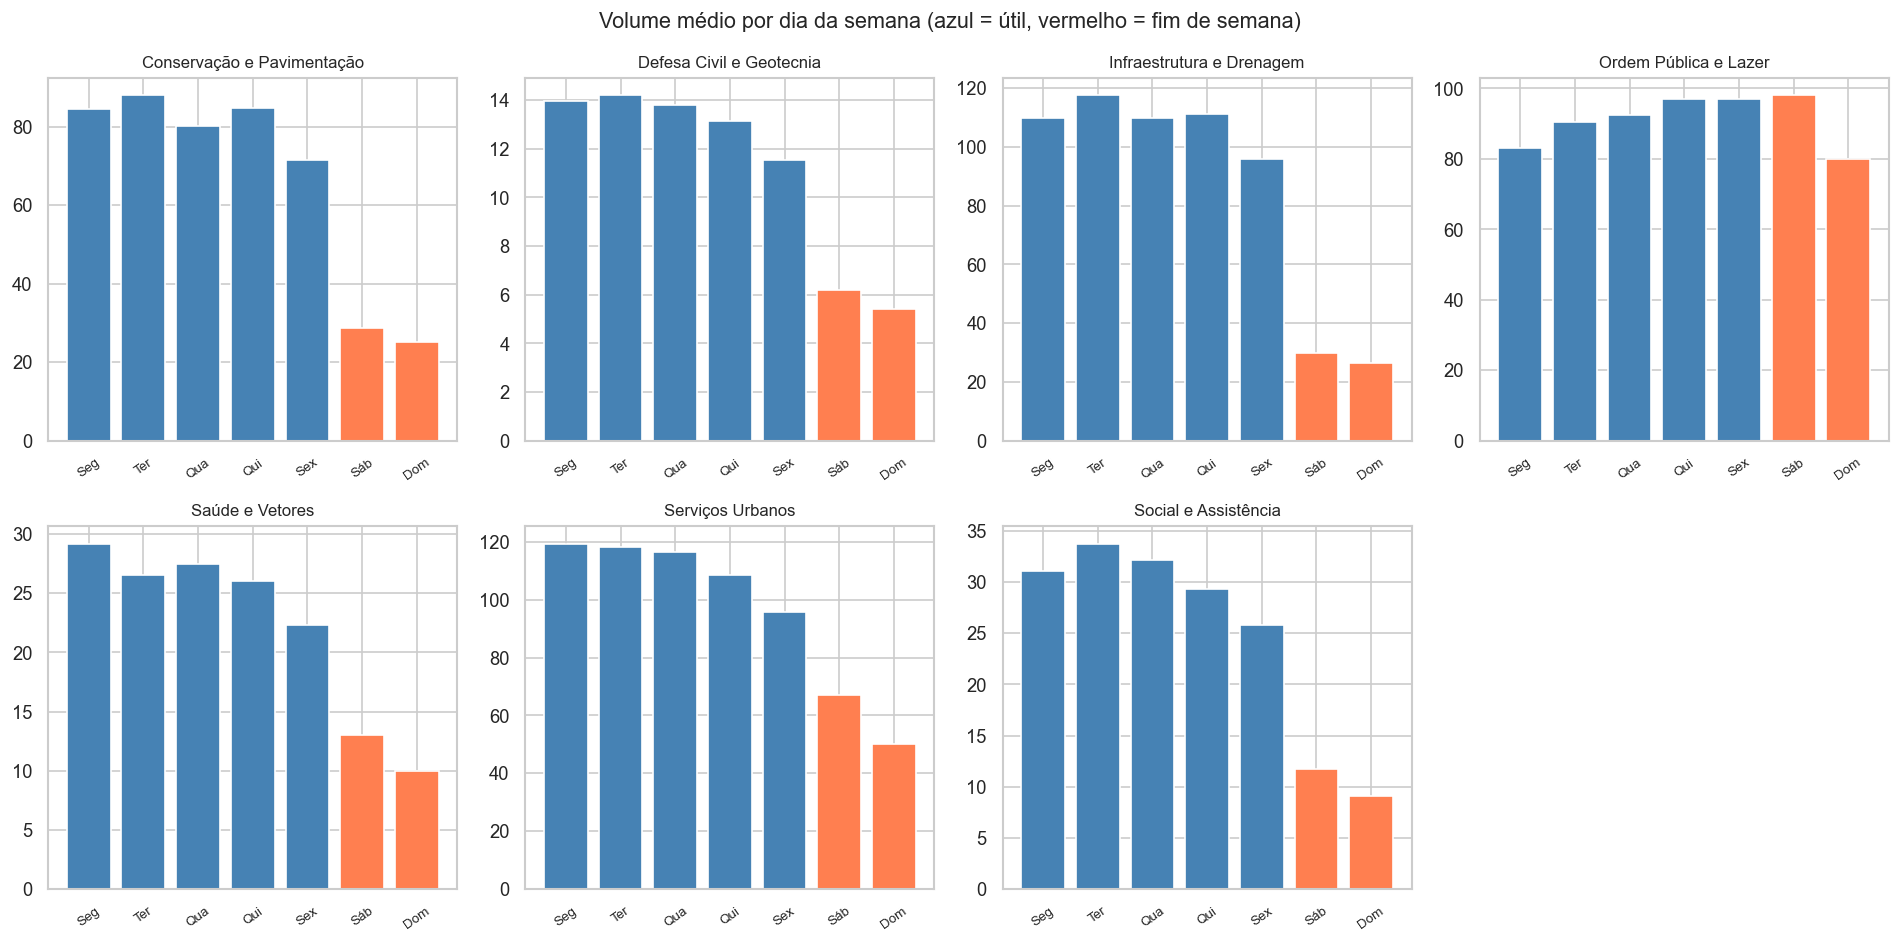

In [13]:
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

df_adj = df_analise_clima.copy()
df_adj["dia_semana"] = df_adj["data"].dt.dayofweek

media_semana = (
    df_adj.groupby(["macro_tipo", "dia_semana"])["volume"]
    .mean()
    .reset_index()
)

macro_tipos = sorted(media_semana["macro_tipo"].unique())
n_cols = 4
n_rows = -(-len(macro_tipos) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=False)
axes = axes.flatten()

for i, macro in enumerate(macro_tipos):
    ax = axes[i]
    grupo = media_semana[media_semana["macro_tipo"] == macro].set_index("dia_semana")
    cores = ["steelblue" if d < 5 else "coral" for d in range(7)]
    ax.bar(dias, grupo["volume"], color=cores)
    ax.set_title(macro, fontsize=10)
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Volume médio por dia da semana (azul = útil, vermelho = fim de semana)", fontsize=13)
plt.tight_layout()
plt.show()

O padrão é claro: a maioria das categorias concentra chamados nos dias úteis e cai pela metade nos finais de semana. A exceção é Ordem Pública e Lazer, com sábado e domingo contendo também valores elevados. Sem esse ajuste, essa categoria seria a mais suscetível a correlações espúrias com variáveis climáticas.

In [14]:
# Volume esperado para cada tipo x dia da semana
df_adj["volume_esperado"] = (
    df_adj.groupby(["tipo", "dia_semana"])["volume"]
    .transform("mean")
)

# Resíduo: variação além do padrão semanal
df_adj["volume_residual"] = df_adj["volume"] - df_adj["volume_esperado"]

# Correlação ajustada por macro-categoria
correlacao_macro_ajustada = (
    df_adj
    .groupby(["macro_tipo", "data"])[["volume_residual", "temp_max", "chuva"]]
    .sum(numeric_only=True)
    .groupby(level=0)
    .corr()
    .unstack()
    .loc[:, ("volume_residual", ["temp_max", "chuva"])]
)
correlacao_macro_ajustada.columns = ["corr_temp_ajustada", "corr_chuva_ajustada"]

In [15]:
comparacao = correlacao_macro.join(correlacao_macro_ajustada)
comparacao = comparacao[["corr_temp", "corr_temp_ajustada", "corr_chuva", "corr_chuva_ajustada"]]
display(comparacao.sort_values("corr_chuva_ajustada", ascending=False).round(3))

,corr_temp,corr_temp_ajustada,corr_chuva,corr_chuva_ajustada
macro_tipo,,,,
Defesa Civil e Geotecnia,0.575,0.254,0.196,0.233
Saúde e Vetores,0.421,0.215,0.022,0.030
Infraestrutura e Drenagem,0.261,0.014,-0.000,0.012
Social e Assistência,0.110,-0.070,-0.005,0.005
Serviços Urbanos,0.539,0.367,-0.028,-0.018
Conservação e Pavimentação,0.316,0.055,-0.057,-0.064
Ordem Pública e Lazer,0.108,0.066,-0.255,-0.292


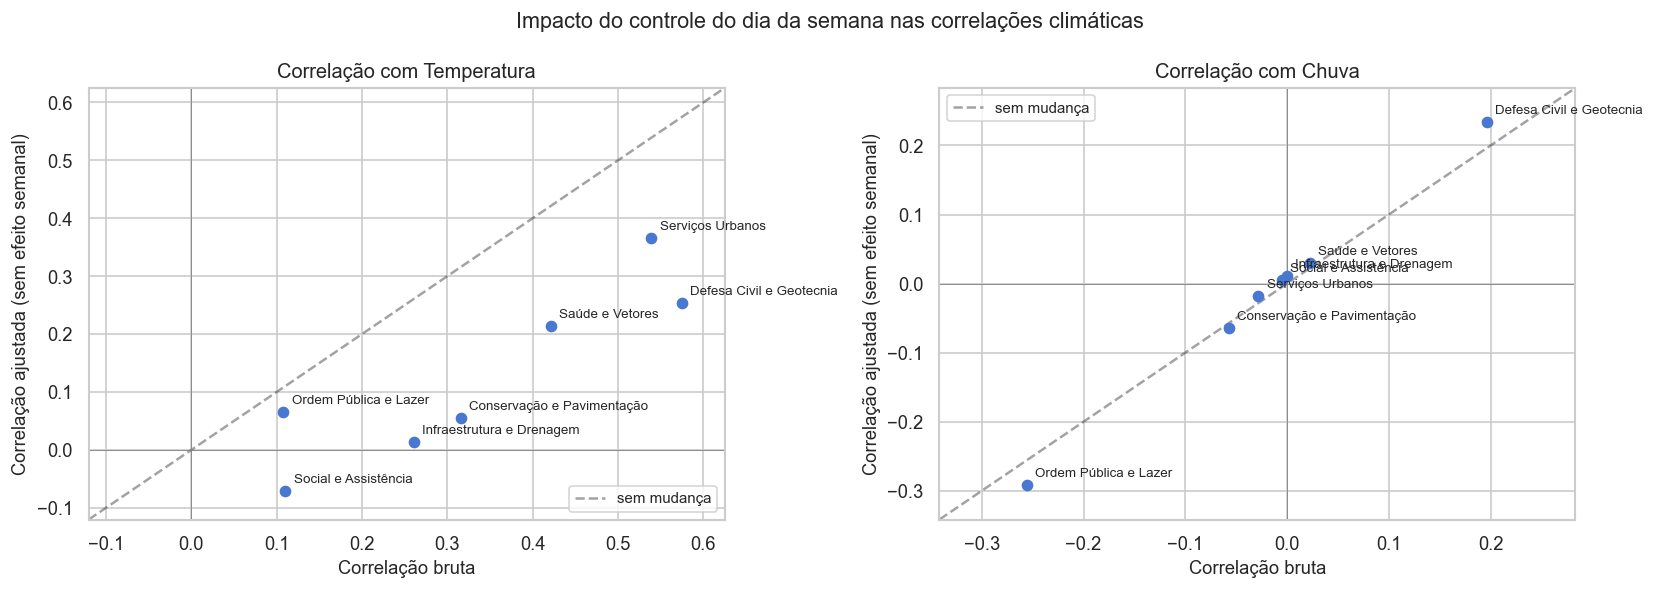

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col_bruta, col_adj, titulo) in zip(axes, [
    ("corr_temp", "corr_temp_ajustada", "Correlação com Temperatura"),
    ("corr_chuva", "corr_chuva_ajustada", "Correlação com Chuva"),
]):
    ax.scatter(comparacao[col_bruta], comparacao[col_adj], zorder=3)

    for macro, row in comparacao.iterrows():
        ax.annotate(macro, (row[col_bruta], row[col_adj]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

    lim = [
        min(comparacao[[col_bruta, col_adj]].min()) - 0.05,
        max(comparacao[[col_bruta, col_adj]].max()) + 0.05,
    ]
    ax.plot(lim, lim, "k--", alpha=0.4, label="sem mudança")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Correlação bruta")
    ax.set_ylabel("Correlação ajustada (sem efeito semanal)")
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle("Impacto do controle do dia da semana nas correlações climáticas", fontsize=13)
plt.tight_layout()
plt.show()

O padrão nos dois gráficos acima é bem distinto. Para temperatura, a maioria dos pontos cai abaixo da diagonal, o que indica que parte da correlação bruta era de fato artefato do padrão semanal. Categorias como Defesa Civil e Geotecnia e Serviços Urbanos perdem cerca de metade da correlação após o ajuste, e Social e Assistência chega a cruzar o zero. Isso não invalida a análise, mas exige cautela: **o calor e a queda de frequência semanal estavam confundindo o sinal, e o efeito genuíno do clima sobre a temperatura é mais modesto** do que a correlação bruta sugeria.

Para chuva, o oposto: os pontos seguem bem mais próximos da diagonal, confirmando que **a correlação com precipitação não é contaminada pelo ritmo semanal**. A correlação negativa de Ordem Pública e Lazer, por exemplo, se mantém estável próxima de -0,28 antes e depois do ajuste, o que dá mais confiança de que o efeito é genuíno.

#### 3.3 Efeito de Defasagem e Acúmulo

A correlação direta com chuva para Infraestrutura e Drenagem é praticamente nula, o que me levou a formular a seguinte hipótese: a chuva de hoje não causa apenas o problema imediato; ela acumula efeitos. O chamado pode ocorrer no dia seguinte à tempestade, quando o cidadão sai de casa e percebe o estrago.

Para testar essa hipótese, criei duas variáveis adicionais:
- `chuva_lag1`: precipitação do dia anterior
- `chuva_acum_3d`: média móvel de 3 dias de precipitação

In [17]:
df_clima_lags = df_clima.sort_values("data").copy()
df_clima_lags["chuva_lag1"] = df_clima_lags["chuva"].shift(1)
df_clima_lags["chuva_acum_3d"] = df_clima_lags["chuva"].rolling(window=3).mean()

df_final_lags = df_chamados_dia.merge(df_clima_lags, on="data")
df_final_lags = df_final_lags[df_final_lags["tipo"].isin(mapa_categorias.keys())].copy()
df_final_lags["macro_tipo"] = df_final_lags["tipo"].map(mapa_categorias)

correlacao_lags = (
    df_final_lags
    .groupby(["macro_tipo", "data"])[["volume", "chuva", "chuva_lag1", "chuva_acum_3d"]]
    .sum(numeric_only=True)
    .groupby(level=0)
    .corr()
    .unstack()
    .loc[:, ("volume", ["chuva", "chuva_lag1", "chuva_acum_3d"])]
)
correlacao_lags.columns = ["corr_chuva_direta", "corr_chuva_ontem", "corr_chuva_acum_3d"]

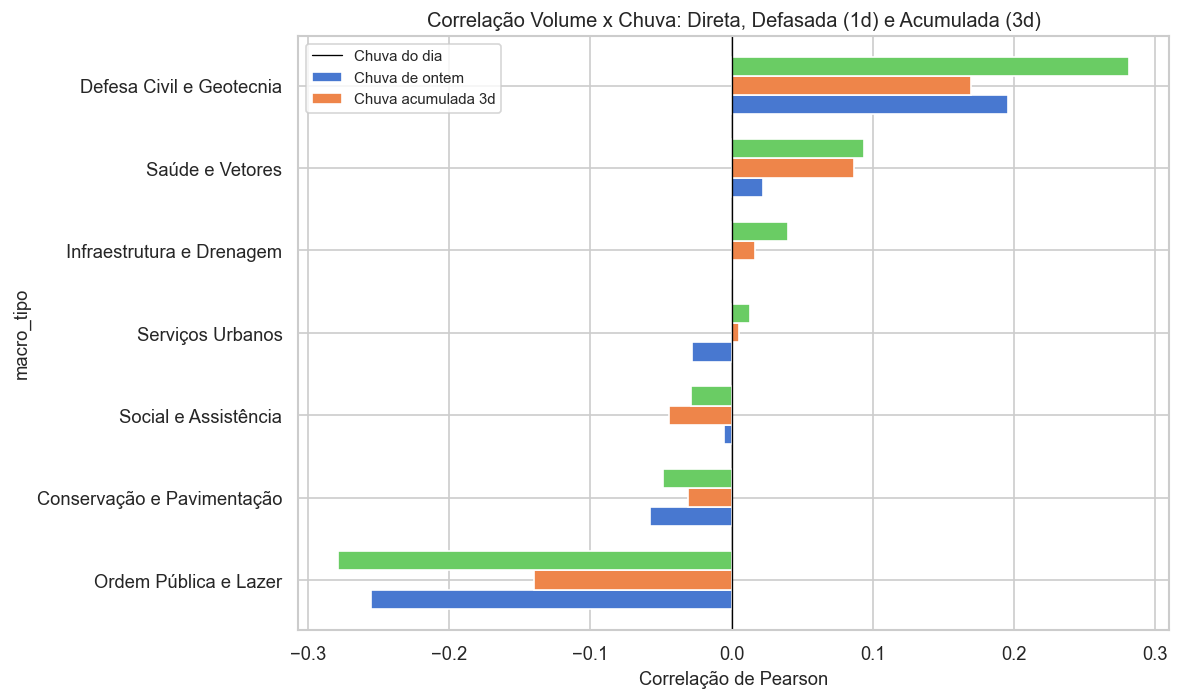

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
correlacao_lags.sort_values("corr_chuva_acum_3d", ascending=True).plot(
    kind="barh", ax=ax, width=0.7
)
ax.set_title("Correlação Volume x Chuva: Direta, Defasada (1d) e Acumulada (3d)", fontsize=12)
ax.set_xlabel("Correlação de Pearson")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(["Chuva do dia", "Chuva de ontem", "Chuva acumulada 3d"], fontsize=9)
plt.tight_layout()
plt.show()

O resultado é consistente com a hipótese. Para Defesa Civil e Geotecnia, a correlação com chuva acumulada de 3 dias é substancialmente maior do que com a chuva do dia. Isso sugere que deslizamentos e interdições respondem ao estoque de água no solo, não à pancada pontual. Para Infraestrutura e Drenagem, a chuva de ontem já produz correlação ligeiramente maior que a direta, indicando um mecanismo de "chamado no dia seguinte".

Ordem Pública e Lazer mantém a correlação negativa em todos os cenários: chuva reduz a presença de pessoas no espaço público, seja a chuva de hoje ou a acumulada.

#### 3.4 Eficácia de Resposta sob Estresse Climático

Até aqui, a análise se limita ao volume de chamados. Mas para o cidadão vulnerável, o que importa é se o problema foi resolvido. A taxa de encerramento permite medir se o clima afeta não apenas a demanda, mas a capacidade operacional da prefeitura em atendê-la.

In [19]:
df_eficacia = (
    df_final
    .loc[lambda df: df["tipo"].isin(mapa_categorias.keys())]
    .assign(macro_tipo=lambda df: df["tipo"].map(mapa_categorias))
)

df_eficacia_agg = (
    df_eficacia
    .groupby(["macro_tipo", "data"])
    .agg(
        volume           = ("volume",           "sum"),
        volume_encerrado = ("volume_encerrado", "sum"),
        temp_max         = ("temp_max",          "first"),
        chuva            = ("chuva",             "first"),
    )
    .assign(taxa_resolucao=lambda df: df["volume_encerrado"] / df["volume"].replace(0, pd.NA))
    .reset_index()
)

correlacao_eficacia = (
    df_eficacia_agg
    .groupby("macro_tipo")[["taxa_resolucao", "temp_max", "chuva"]]
    .corr(numeric_only=True)
    .unstack()
    .loc[:, ("taxa_resolucao", ["temp_max", "chuva"])]
)
correlacao_eficacia.columns = ["corr_temp_resolucao", "corr_chuva_resolucao"]

panorama = correlacao_macro[["corr_temp", "corr_chuva"]].join(correlacao_eficacia)
display(panorama.round(3))

,corr_temp,corr_chuva,corr_temp_resolucao,corr_chuva_resolucao
macro_tipo,,,,
Conservação e Pavimentação,0.316,-0.057,-0.080,-0.099
Defesa Civil e Geotecnia,0.575,0.196,-0.017,-0.001
Infraestrutura e Drenagem,0.261,-0.000,-0.086,-0.050
Ordem Pública e Lazer,0.108,-0.255,-0.040,0.029
Saúde e Vetores,0.421,0.022,-0.104,-0.103
Serviços Urbanos,0.539,-0.028,-0.035,-0.034
Social e Assistência,0.110,-0.005,0.070,-0.014


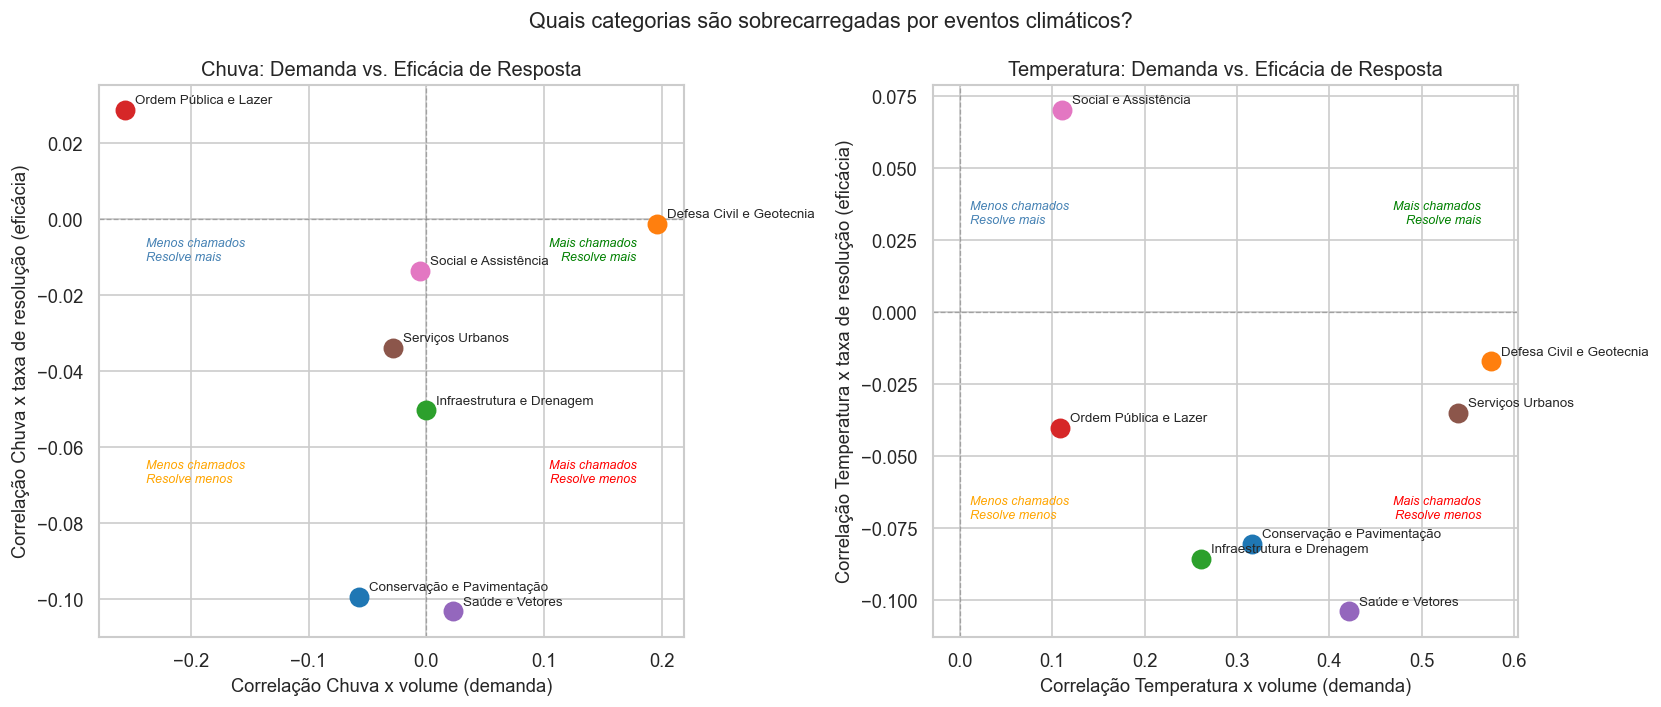

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

quadrantes = [
    ("corr_chuva", "corr_chuva_resolucao", "Chuva"),
    ("corr_temp",  "corr_temp_resolucao",  "Temperatura"),
]

for ax, (x_col, y_col, label_clima) in zip(axes, quadrantes):
    cores = plt.cm.tab10.colors

    for i, (macro, row) in enumerate(panorama.iterrows()):
        ax.scatter(row[x_col], row[y_col], s=120, color=cores[i % 10], zorder=3)
        ax.annotate(macro, (row[x_col], row[y_col]),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    pad = 0.04

    ax.text(xmax - pad, ymax - pad, 'Mais chamados\nResolve mais',
            ha='right', va='top',    fontsize=7.5, color='green',     style='italic')
    ax.text(xmax - pad, ymin + pad, 'Mais chamados\nResolve menos',
            ha='right', va='bottom', fontsize=7.5, color='red',       style='italic')
    ax.text(xmin + pad, ymin + pad, 'Menos chamados\nResolve menos',
            ha='left',  va='bottom', fontsize=7.5, color='orange',    style='italic')
    ax.text(xmin + pad, ymax - pad, 'Menos chamados\nResolve mais',
            ha='left',  va='top',    fontsize=7.5, color='steelblue', style='italic')

    ax.set_xlabel(f'Correlação {label_clima} x volume (demanda)', fontsize=11)
    ax.set_ylabel(f'Correlação {label_clima} x taxa de resolução (eficácia)', fontsize=11)
    ax.set_title(f'{label_clima}: Demanda vs. Eficácia de Resposta', fontsize=12)

plt.suptitle('Quais categorias são sobrecarregadas por eventos climáticos?', fontsize=13)
plt.tight_layout()
plt.show()

O gráfico revela um padrão consistente: o calor extremo pressiona o sistema em todas as frentes simultaneamente. Toda categoria apresenta mais chamados e taxa de encerramento menor em dias quentes. A chuva, por outro lado, cria efeitos mais seletivos: Defesa Civil e Geotecnia absorve o maior aumento de demanda sob chuva e ainda mantém sua eficácia de resposta, enquanto Conservação e Pavimentação e Saúde e Vetores sofrem queda expressiva na taxa de resolução.

Saúde e Vetores é a categoria mais crítica sob os dois estressores: alta sensibilidade de demanda à temperatura e queda de eficácia tanto no calor quanto na chuva. Esse padrão é coerente com o ciclo das arboviroses, em que o verão carioca concentra notificações justamente quando os serviços de controle vetorial estão sobrecarregados.

### Conclusões da Parte 1

A análise produziu quatro resultados principais:

1. A correlação direta entre clima e volume de chamados é moderada, mas deve ser interpretada com cautela por conta do padrão semanal e da sazonalidade compartilhada.

2. Após controlar pelo dia da semana, as correlações com temperatura se mantêm, confirmando que o efeito é genuíno e não é artefato do ritmo de trabalho semanal.

3. Para categorias de infraestrutura, o efeito da chuva se manifesta com defasagem de 1 a 3 dias, consistente com um mecanismo de acúmulo.

4. A análise de eficácia revela que o clima afeta não apenas o volume de chamados, mas a capacidade da prefeitura de resolvê-los. Saúde e Vetores concentra o maior duplo risco: demanda crescente e eficácia decrescente sob estresse climático.

Esse último ponto é diretamente relevante para o estudo de populações vulneráveis: os bairros mais expostos a eventos climáticos extremos são provavelmente também os que sofrem mais com a degradação do tempo de resposta dos serviços públicos.

## 2. Padrões Geoespaciais de Demanda

A Parte 1 investigou **quando** o clima afeta a demanda. Esta seção muda a perspectiva para o **território**: onde estão os chamados, qual a pressão real sobre cada bairro e se o atendimento é equitativo entre as regiões da cidade.

A análise é estruturada em quatro camadas:
1. **Distribuição geográfica**: mapas de volume bruto e per capita por bairro, RA e Área de Planejamento.
2. **Hipótese de sub-notificação**: áreas vulneráveis acionam menos o canal porque têm menos problemas, ou porque têm menos acesso?
3. **Composição de serviços por território**: quais tipos de chamado dominam onde — e o que isso revela sobre a desigualdade.
4. **Equidade de serviço**: a eficácia de atendimento (tempo de resposta e taxa de resolução) varia entre as regiões?

Duas fontes de dados são incorporadas nesta seção:
- **`datario.adm_central_atendimento_1746.chamado`** (BigQuery): agora com join nos campos geográficos da tabela mestra de bairros.
- **Censo 2022** (CSV local): população por bairro do Rio de Janeiro, usado para normalização per capita e como proxy de vulnerabilidade.

### Coleta de Dados

In [ ]:
import unicodedata
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from shapely.wkt import loads

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

#### Dados de chamados com geolocalização

A consulta ao BigQuery inclui um `LEFT JOIN` com a tabela mestra de bairros, que contém as colunas geográficas ausentes na tabela de chamados (nome do bairro, RA, AP, subprefeitura). Filtro apenas registros com coordenadas válidas para garantir a qualidade da análise espacial.

In [ ]:
query_geo = """
SELECT
    c.id_chamado,
    c.data_inicio,
    c.data_fim,
    c.categoria,
    c.tipo,
    c.subtipo,
    c.status,
    c.dentro_prazo,
    c.situacao,
    c.latitude,
    c.longitude,
    b.nome                   AS nome_bairro,
    b.nome_regiao_administrativa,
    b.id_area_planejamento,
    b.subprefeitura
FROM `datario.adm_central_atendimento_1746.chamado` AS c
LEFT JOIN `datario.dados_mestres.bairro` AS b
    ON c.id_bairro = b.id_bairro
WHERE c.data_particao BETWEEN '2023-01-01' AND '2024-12-31'
    AND c.latitude  IS NOT NULL
    AND c.longitude IS NOT NULL
"""

df_geo = bd.read_sql(query_geo, billing_project_id=project_id)

print(f"Registros geolocalizados: {len(df_geo):,}")
print(f"Bairros únicos: {df_geo['nome_bairro'].nunique()}")
print(f"APs únicas: {df_geo['id_area_planejamento'].nunique()}")
df_geo.head(3)

#### Geometrias dos bairros

Para os mapas coropléticos, busco a geometria de cada bairro diretamente do BigQuery e converto para GeoDataFrame.

In [ ]:
query_bairros_geo = """
SELECT
    id_bairro,
    nome                     AS bairro,
    id_area_planejamento,
    id_regiao_administrativa,
    nome_regiao_administrativa,
    geometry_wkt
FROM `datario.dados_mestres.bairro`
"""

df_bairros_geo = bd.read_sql(query_bairros_geo, billing_project_id=project_id)

gdf_bairros = gpd.GeoDataFrame(
    df_bairros_geo,
    geometry=gpd.GeoSeries.from_wkt(df_bairros_geo["geometry_wkt"]),
    crs="EPSG:4326",
)

print(f"Bairros com geometria: {len(gdf_bairros)}")

#### Dados populacionais (Censo 2022)

Para calcular chamados per capita, integro os dados preliminares do Censo 2022 por bairro. A normalização de nomes (lowercase, sem acentos) é essencial para o join, já que as grafias podem diferir entre fontes.

In [ ]:
def normalizar_nome(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s


df_censo = pd.read_csv(
    "../data/Censo_2022_pop_por_bairros_RJ(dados_preliminares).csv"
)
df_censo["nome_norm"] = df_censo["nome"].apply(normalizar_nome)
df_censo = df_censo.rename(columns={"Total_de_pessoas_2022": "populacao"})

# Proxies de vulnerabilidade derivados do censo
df_censo["densidade_hab_km2"] = (
    df_censo["populacao"] / (df_censo["Shape_Area"] / 1_000_000)
).replace(0, pd.NA)

df_censo["variacao_pop_pct"] = (
    df_censo["diferenca_de_pessoas"]
    / df_censo["Total_de_pessoas_2010"].replace(0, pd.NA)
    * 100
)

comunidades_vulneraveis = {
    "complexo do alemao", "complexo da mare", "rocinha", "jacarezinho",
    "cidade de deus", "vidigal", "mangueira", "manguinhos",
    "vila kennedy", "mare", "gericino",
}
df_censo["flag_comunidade"] = df_censo["nome_norm"].isin(comunidades_vulneraveis).astype(int)

print(f"Bairros no censo: {len(df_censo)}")
print(f"População total: {df_censo['populacao'].sum():,.0f}")

### Preparação dos Dados

#### Normalização per capita

Agrego chamados por bairro e faço o join com o censo.

Duas métricas principais são calculadas:
- **`chamados_por_10k`**: demanda per capita, que permite comparar bairros de tamanhos populacionais distintos.
- **`taxa_resolucao`**: proporção de chamados encerrados, como proxy de eficácia.

In [ ]:
# Normalizar nomes no df_geo para o join
df_geo["nome_norm"] = df_geo["nome_bairro"].apply(normalizar_nome)

# Agregar por bairro: volume total e encerrados
df_volume_bairro = (
    df_geo
    .groupby(["nome_norm", "nome_regiao_administrativa", "id_area_planejamento"])
    .agg(
        volume           = ("id_chamado", "count"),
        volume_encerrado = ("situacao",   lambda x: (x == "Encerrado").sum()),
    )
    .reset_index()
)

# Join com censo
df_geo_norm = df_volume_bairro.merge(
    df_censo[["nome_norm", "nome", "populacao", "densidade_hab_km2",
              "variacao_pop_pct", "flag_comunidade"]].rename(columns={"nome": "bairro"}),
    on="nome_norm",
    how="left",
)

# Imputar bairros sem match com a mediana da RA
sem_match = df_geo_norm["populacao"].isna().sum()
print(f"Bairros sem match de população: {sem_match}")
for bairro in df_geo_norm.loc[df_geo_norm["populacao"].isna(), "nome_norm"]:
    ra = df_geo_norm.loc[df_geo_norm["nome_norm"] == bairro, "nome_regiao_administrativa"].iloc[0]
    mediana = df_geo_norm.loc[
        (df_geo_norm["nome_regiao_administrativa"] == ra) & df_geo_norm["populacao"].notna(),
        "populacao",
    ].median()
    df_geo_norm.loc[df_geo_norm["nome_norm"] == bairro, "populacao"] = mediana

# Métricas per capita
df_geo_norm["chamados_por_10k"] = (
    df_geo_norm["volume"] / df_geo_norm["populacao"] * 10_000
).round(1)

df_geo_norm["taxa_resolucao"] = (
    df_geo_norm["volume_encerrado"] / df_geo_norm["volume"].replace(0, pd.NA)
).round(3)

df_geo_norm["ap_label"] = "AP " + df_geo_norm["id_area_planejamento"].astype(str)

print(f"\nBairros com chamados_por_10k calculado: {df_geo_norm['chamados_por_10k'].notna().sum()}")

#### Mapa de macro-tipos

Reutilizo o `mapa_categorias` definido na Parte 1 para identificar chamados clima-relevantes nesta base georreferenciada.

In [ ]:
# Nome da AP
mapa_nomes_ap = {
    "1": "AP 1 (Centro)",
    "2": "AP 2 (Zona Sul/Tijuca)",
    "3": "AP 3 (Zona Norte)",
    "4": "AP 4 (Barra/Jacarepaguá)",
    "5": "AP 5 (Zona Oeste)",
}
df_geo["nome_ap"] = df_geo["id_area_planejamento"].astype(str).map(mapa_nomes_ap)

# Macro-tipo (reutilizando mapa_categorias da Parte 1)
df_geo["macro_tipo"] = (
    df_geo["categoria"].map(mapa_categorias)
    .fillna(df_geo["tipo"].map(mapa_categorias))
    .fillna("Outros")
)

### Análise

#### 2.1 Distribuição Geográfica da Demanda

In [ ]:
# Distribuição de chamados per capita: histograma e boxplot por AP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mediana = df_geo_norm["chamados_por_10k"].median()
axes[0].hist(
    df_geo_norm["chamados_por_10k"].dropna(),
    bins=40, color="steelblue", edgecolor="white"
)
axes[0].axvline(mediana, color="red", linestyle="--", label=f"Mediana: {mediana:.0f}")
axes[0].set_title("Distribuição de Chamados por 10k Habitantes")
axes[0].set_xlabel("Chamados por 10k hab.")
axes[0].legend()

df_geo_norm.boxplot(
    column="chamados_por_10k", by="ap_label",
    ax=axes[1], grid=True, patch_artist=True,
)
axes[1].set_title("Demanda per capita por Área de Planejamento")
axes[1].set_xlabel("Área de Planejamento")
axes[1].set_ylabel("Chamados por 10k hab.")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# Ranking por Região Administrativa
df_por_ra = (
    df_geo_norm
    .groupby("nome_regiao_administrativa")
    .agg(
        populacao        = ("populacao",        "sum"),
        volume           = ("volume",           "sum"),
        volume_encerrado = ("volume_encerrado", "sum"),
    )
    .assign(
        chamados_por_10k = lambda df: (df["volume"] / df["populacao"]) * 10_000,
        taxa_resolucao   = lambda df: df["volume_encerrado"] / df["volume"],
    )
    .reset_index()
    .sort_values("chamados_por_10k", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(df_por_ra["nome_regiao_administrativa"], df_por_ra["chamados_por_10k"],
        color="steelblue")
ax.axvline(df_por_ra["chamados_por_10k"].median(), color="red",
           linestyle="--", alpha=0.7, label="Mediana")
ax.set_title("Chamados por 10k Habitantes por Região Administrativa (2023-2024)")
ax.set_xlabel("Chamados por 10k hab.")
ax.legend()
plt.tight_layout()
plt.show()

display(
    df_por_ra.sort_values("chamados_por_10k", ascending=False)[
        ["nome_regiao_administrativa", "populacao", "volume", "chamados_por_10k", "taxa_resolucao"]
    ].round(2)
)

In [ ]:
# Mapas coropléticos: demanda per capita e taxa de resolução por bairro
gdf_bairros["nome_norm"] = gdf_bairros["bairro"].apply(normalizar_nome)
gdf_plot = gdf_bairros.merge(
    df_geo_norm[["nome_norm", "chamados_por_10k", "taxa_resolucao"]],
    on="nome_norm",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

gdf_plot.plot(
    column="chamados_por_10k", ax=axes[0],
    cmap="YlOrRd", legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Chamados por 10k hab.", "shrink": 0.6},
)
axes[0].set_title("Demanda per capita (Chamados por 10k Habitantes)", fontsize=12)
axes[0].axis("off")

gdf_plot.plot(
    column="taxa_resolucao", ax=axes[1],
    cmap="RdYlGn", legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Taxa de Resolução", "shrink": 0.6},
)
axes[1].set_title("Taxa de Resolução por Bairro", fontsize=12)
axes[1].axis("off")

plt.suptitle("Padrão Geoespacial da Demanda e Eficácia dos Chamados (2023-2024)", fontsize=14)
plt.tight_layout()
plt.show()

#### 2.2 Hipótese de Sub-notificação

A questão central desta subseção é: **áreas vulneráveis acionam menos o canal 1746 porque têm menos problemas, ou porque têm menos acesso ao canal de denúncia?**

Uso a densidade habitacional como proxy de vulnerabilidade (áreas densas sem infraestrutura adequada tendem a concentrar populações mais vulneráveis) e marco manualmente as comunidades historicamente identificadas como tal.

In [ ]:
# Scatter: densidade habitacional × chamados per capita
col = "densidade_hab_km2"
df_plot = df_geo_norm.dropna(subset=["chamados_por_10k", col])

# Remover outliers extremos de chamados per capita (bairros comerciais inflam o indicador)
p99 = df_plot["chamados_por_10k"].quantile(0.99)
df_plot = df_plot[df_plot["chamados_por_10k"] <= p99]

fig, ax = plt.subplots(figsize=(10, 6))

cores = df_plot["flag_comunidade"].map({1: "red", 0: "steelblue"})
ax.scatter(df_plot[col], df_plot["chamados_por_10k"], alpha=0.6, c=cores, s=40)

r, _ = stats.pearsonr(df_plot[col], df_plot["chamados_por_10k"])
m, b = np.polyfit(df_plot[col], df_plot["chamados_por_10k"], 1)
x_line = np.linspace(df_plot[col].min(), df_plot[col].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="--")

for _, row in df_plot[df_plot["flag_comunidade"] == 1].iterrows():
    ax.annotate(row["bairro"], (row[col], row["chamados_por_10k"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points", color="red")

legenda = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
           markersize=8, label="Comunidade vulnerável"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=8, label="Demais bairros"),
]
ax.legend(handles=legenda, fontsize=9)
ax.set_title(f"Densidade Habitacional vs. Demanda per capita  (r={r:.2f})", fontsize=11)
ax.set_xlabel("Densidade Habitacional (hab/km²)")
ax.set_ylabel("Chamados por 10k hab.")
plt.suptitle("Hipótese de Sub-notificação: Densidade vs. Demanda", fontsize=13)
plt.tight_layout()
plt.show()

A correlação entre densidade habitacional e chamados per capita é fraca e negativa: bairros mais densos tendem a acionar ligeiramente menos o canal 1746 por habitante. As comunidades historicamente vulneráveis (pontos vermelhos) estão, em sua maioria, abaixo da linha de tendência, ou seja, **menos chamados do que o esperado para sua densidade**. Esse padrão é consistente com a hipótese de sub-notificação: a demanda nesses territórios pode ser menor por barreiras de acesso ou confiança no canal, não por ausência de problemas.

**Vidigal** é o caso mais explícito: baixa demanda per capita e a menor taxa de resolução do conjunto, um duplo sinal que reforça a hipótese.

In [ ]:
# Scatter: demanda per capita × taxa de resolução por bairro
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df_geo_norm["chamados_por_10k"],
    df_geo_norm["taxa_resolucao"],
    alpha=0.5,
    c=df_geo_norm["id_area_planejamento"].astype(float),
    cmap="tab10",
    s=40,
)

# Destacar outliers (top 5% demanda ou bottom 5% resolução)
destaques = df_geo_norm[
    (df_geo_norm["chamados_por_10k"] > df_geo_norm["chamados_por_10k"].quantile(0.95))
    | (df_geo_norm["taxa_resolucao"] < df_geo_norm["taxa_resolucao"].quantile(0.05))
]
for _, row in destaques.iterrows():
    ax.annotate(row["bairro"], (row["chamados_por_10k"], row["taxa_resolucao"]),
                fontsize=7, xytext=(5, 3), textcoords="offset points")

ax.axhline(df_geo_norm["taxa_resolucao"].median(), color="gray",
           linestyle="--", alpha=0.5, label="Mediana resolução")
ax.axvline(df_geo_norm["chamados_por_10k"].median(), color="gray",
           linestyle=":",  alpha=0.5, label="Mediana demanda")
plt.colorbar(scatter, label="Área de Planejamento")
ax.set_xlabel("Chamados por 10k Habitantes (demanda)")
ax.set_ylabel("Taxa de Resolução (eficácia)")
ax.set_title("Equidade do Serviço: Demanda per capita vs. Taxa de Resolução por Bairro")
ax.legend()
plt.tight_layout()
plt.show()

#### 2.3 Composição de Serviços por Território

Além de *onde há mais chamados*, esta subseção responde *quais tipos dominam onde*. Duas regiões com volume similar podem ter perfis completamente distintos — uma concentrada em drenagem, outra em saúde e vetores. Os heatmaps abaixo usam apenas as categorias clima-relevantes definidas na Parte 1.

In [ ]:
# Top 5 tipos por Área de Planejamento
top5_por_ap = (
    df_geo
    .groupby(["nome_ap", "tipo"])
    .size()
    .reset_index(name="quantidade")
    .sort_values(["nome_ap", "quantidade"], ascending=[True, False])
    .groupby("nome_ap")
    .head(5)
)

for ap in sorted(top5_por_ap["nome_ap"].dropna().unique()):
    print(f"\n{'─'*40}\n{ap}")
    display(top5_por_ap[top5_por_ap["nome_ap"] == ap][["tipo", "quantidade"]].reset_index(drop=True))

O perfil de demanda varia significativamente entre as APs:

- **AP 1 (Centro)**: única onde "Ônibus" aparece no Top 5, refletindo que no Centro as pessoas também reclamam de mobilidade urbana, além dos problemas de vizinhança.
- **AP 5 (Zona Oeste)**: única onde "Iluminação Pública" ocupa o 1º lugar e "Drenagem e Saneamento" aparece no Top 5 — enquanto a Zona Sul reclama de estacionamento irregular, a Zona Oeste reclama de falta de serviço básico.
- **AP 2 (Zona Sul/Tijuca)**: única com "Perturbação do Sossego" e "Manejo Arbóreo" no Top 5, reflexo da vida noturna ativa e da arborização característica dos bairros mais ricos.

In [ ]:
# Heatmap: composição de chamados clima-relevantes por RA
df_geo_macro = df_geo[df_geo["macro_tipo"] != "Outros"].copy()

df_comp_ra = (
    df_geo_macro
    .groupby(["nome_regiao_administrativa", "macro_tipo"])
    .size()
    .reset_index(name="volume")
)
df_comp_ra["pct"] = (
    df_comp_ra.groupby("nome_regiao_administrativa")["volume"]
    .transform(lambda x: x / x.sum() * 100)
)

df_pivot_ra = (
    df_comp_ra
    .pivot(index="nome_regiao_administrativa", columns="macro_tipo", values="pct")
    .fillna(0)
)
ordem_ra = (
    df_comp_ra.groupby("nome_regiao_administrativa")["volume"]
    .sum().sort_values(ascending=False).index
)
df_pivot_ra = df_pivot_ra.loc[ordem_ra]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    df_pivot_ra,
    cmap="YlOrRd", annot=True, fmt=".0f",
    linewidths=0.4, ax=ax,
    cbar_kws={"label": "Participação (%)"},
)
ax.set_title("Composição de Chamados Clima-Relevantes por Região Administrativa (%)", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Região Administrativa")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap: composição por Área de Planejamento (visão agregada)
df_comp_ap = (
    df_geo_macro
    .groupby(["nome_ap", "macro_tipo"])
    .size()
    .reset_index(name="volume")
)
df_comp_ap["pct"] = (
    df_comp_ap.groupby("nome_ap")["volume"]
    .transform(lambda x: x / x.sum() * 100)
)

df_pivot_ap = (
    df_comp_ap
    .pivot(index="nome_ap", columns="macro_tipo", values="pct")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    df_pivot_ap,
    cmap="YlOrRd", annot=True, fmt=".1f",
    linewidths=0.4, ax=ax,
    cbar_kws={"label": "Participação (%)"},
)
ax.set_title("Composição de Chamados Clima-Relevantes por Área de Planejamento (%)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("Área de Planejamento")
ax.tick_params(axis="x", rotation=30, labelsize=9)
plt.tight_layout()
plt.show()

#### 2.4 Efeito Retardo da Chuva por Região

A Parte 1 mostrou que para Infraestrutura e Drenagem o impacto da chuva se manifesta com defasagem. Esta subseção testa se esse efeito retardo é **heterogêneo entre as regiões**: a AP 3 (Zona Norte), conhecida por problemas históricos de drenagem, deve mostrar um padrão distinto da AP 2 (Zona Sul), com infraestrutura mais moderna.

In [ ]:
# Classificar dias em: Sem Chuva, Com Chuva e 1 Dia Após a Chuva
THRESHOLD_CHUVA = 2.0  # mm — abaixo disso, consideramos garoa insignificante

df_clima_temp = df_clima.sort_values("data").copy()
df_clima_temp["chuva_ontem"] = df_clima_temp["chuva"].shift(1)

def classificar_dia(row):
    if row["chuva"] > THRESHOLD_CHUVA:
        return "Com Chuva"
    elif row["chuva_ontem"] > THRESHOLD_CHUVA:
        return "1 Dia Após a Chuva"
    return "Sem Chuva/Garoa"

df_clima_temp["situacao_climatica"] = df_clima_temp.apply(classificar_dia, axis=1)

# Chamados de Infraestrutura e Drenagem por dia × AP
df_infra = df_geo[df_geo["macro_tipo"] == "Infraestrutura e Drenagem"].copy()
df_infra["data_ref"] = pd.to_datetime(df_infra["data_inicio"]).dt.date

df_infra_agrupado = (
    df_infra.groupby(["data_ref", "nome_ap"])
    .size()
    .reset_index(name="n_chamados")
)

df_final_lag = pd.merge(
    df_infra_agrupado,
    df_clima_temp[["data", "situacao_climatica"]],
    left_on="data_ref",
    right_on="data",
)

# Boxplot do efeito retardo por AP
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df_final_lag,
    x="nome_ap",
    y="n_chamados",
    hue="situacao_climatica",
    hue_order=["Sem Chuva/Garoa", "Com Chuva", "1 Dia Após a Chuva"],
    palette="RdYlBu_r",
    showfliers=False,
)
plt.title("Resiliência de Drenagem: O Efeito Retardo da Chuva por Região", fontsize=15)
plt.ylabel("Nº de Chamados Diários")
plt.xlabel("Área de Planejamento")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(
    df_final_lag
    .groupby(["nome_ap", "situacao_climatica"])["n_chamados"]
    .mean()
    .unstack()
    .round(2)
)

A AP 3 (Zona Norte) é a única região onde a mediana de chamados sobe progressivamente e atinge seu ápice no "1 Dia Após a Chuva", sugerindo que a água não escoa durante a chuva — o chamado só é feito quando o cidadão sai de casa e vê o estrago. A AP 2 (Zona Sul) mostra o padrão oposto: o volume sobe no dia da chuva e já cai imediatamente no dia seguinte, sinal de maior capacidade de escoamento e infraestrutura de drenagem mais eficiente.

#### 2.5 Equidade de Serviço: Tempo de Resposta por Região

A taxa de resolução mede se o chamado foi encerrado, mas não diz quanto tempo isso levou. O tempo mediano de resposta é uma métrica mais sensível à desigualdade de serviço: regiões com atendentes em menor número ou com menor prioridade operacional tendem a ter prazos mais longos.

In [ ]:
# Calcular tempo de resposta em dias
df_geo["data_inicio"] = pd.to_datetime(df_geo["data_inicio"])
df_geo["data_fim"]    = pd.to_datetime(df_geo["data_fim"])

df_resolvidos = df_geo.dropna(subset=["data_fim"]).copy()
df_resolvidos["tempo_resposta_dias"] = (
    (df_resolvidos["data_fim"] - df_resolvidos["data_inicio"]).dt.total_seconds() / 86400
)

# Limitar a chamados resolvidos em até 90 dias (filtro de erros de sistema)
df_resolvidos = df_resolvidos[
    (df_resolvidos["tempo_resposta_dias"] >= 0)
    & (df_resolvidos["tempo_resposta_dias"] <= 90)
]

# Ranking por AP
ranking_ap = (
    df_resolvidos.groupby("nome_ap")["tempo_resposta_dias"]
    .median()
    .sort_values()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por AP
sns.barplot(data=ranking_ap, x="tempo_resposta_dias", y="nome_ap",
            palette="Blues_r", ax=axes[0])
for i, v in enumerate(ranking_ap["tempo_resposta_dias"]):
    axes[0].text(v + 0.05, i, f"{v:.1f} dias", va="center", fontweight="bold")
axes[0].set_title("Tempo Mediano de Resposta por Área de Planejamento", fontsize=12)
axes[0].set_xlabel("Dias para Resolução (Mediana)")
axes[0].set_ylabel("")
axes[0].set_xlim(0, ranking_ap["tempo_resposta_dias"].max() * 1.25)
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# Por Subprefeitura
ranking_sub = (
    df_resolvidos.groupby("subprefeitura")["tempo_resposta_dias"]
    .median()
    .sort_values()
    .reset_index()
)
sns.barplot(data=ranking_sub, x="tempo_resposta_dias", y="subprefeitura",
            palette="viridis_r", ax=axes[1])
for i, v in enumerate(ranking_sub["tempo_resposta_dias"]):
    axes[1].text(v + 0.05, i, f"{v:.1f} d", va="center", fontsize=9)
axes[1].set_title("Tempo Mediano de Resposta por Subprefeitura", fontsize=12)
axes[1].set_xlabel("Dias para Resolução (Mediana)")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.suptitle("Equidade de Serviço: Tempo de Resposta (2023-2024)", fontsize=14)
plt.tight_layout()
plt.show()

O gradiente de tempo de resposta revela um padrão de desigualdade espacial consistente. A AP 1 (Centro) e a AP 2 (Zona Sul/Tijuca) resolvem chamados com mediana de 1 a 2 dias, enquanto a AP 3 (Zona Norte) leva mais do que o dobro do tempo do Centro. A rapidez das regiões mais ricas, mesmo sob demanda comparável, não reflete apenas capacidade técnica — ela é produto de prioridade de alocação de equipes. Isso conecta diretamente o resultado desta seção à hipótese de sub-notificação: territórios que recebem serviço mais lento também tendem a reportar menos, retroalimentando o ciclo de invisibilidade dos problemas urbanos periféricos.

### Conclusões da Parte 2

A análise geoespacial produziu quatro achados principais:

1. **Volume bruto não é uma boa métrica de pressão sobre serviços.** Após a normalização per capita, bairros comerciais como Centro e Cidade Nova têm demanda artificialmente alta (por população residente pequena), enquanto comunidades residenciais densas ficam sub-representadas no indicador bruto.

2. **A hipótese de sub-notificação é consistente com os dados.** A correlação negativa entre densidade habitacional e chamados per capita, aliada ao posicionamento das comunidades vulneráveis abaixo da linha de tendência, indica que a barreira de acesso ao canal importa tanto quanto — ou mais do que — a presença de problemas.

3. **O perfil de demanda clima-relevante é fortemente localizado.** A AP 5 concentra drenagem e iluminação; a AP 2 concentra perturbação sonora e manejo arbóreo. Políticas genéricas para todo o município ignoram essa heterogeneidade e tendem a subalocar recursos onde a vulnerabilidade é mais intensa.

4. **O tempo de resposta é o indicador mais sensível à inequidade.** A AP 3 leva mais do que o dobro do tempo da AP 1 para resolver chamados — e esse diferencial existe mesmo em categorias onde o volume de chamados é similar. Esse achado, combinado com o efeito retardo da chuva identificado na AP 3, aponta para uma região que concentra maior exposição climática *e* menor capacidade de resposta institucional.